In [1]:
using DifferentialEquations, Plots

расстояние от лодки до катера

In [2]:
k = 9.4

9.4

вычисление x для двух случаев

In [3]:
x1 = k/4.7
x2 = k/2.7

3.4814814814814814

начальные условия для 1 случая

In [4]:
r0 = x1
theta0 = (0.0, 2*pi) #диапазон значений

(0.0, 6.283185307179586)

Начальные условия для 2 случая

In [5]:
r0_2 = x2
theta0_2 = (-pi, pi)

fi=pi/4 #угол под которым двигается лодка

x(t) = tan(fi) * t #движение лодки браконьеров

f(r, p, t) = r/sqrt(12.69) #Функция, описывающая движение катера береговой охраны (ДУ)

f (generic function with 1 method)

Постановка ДУ с ЗК для 1 случая

In [6]:
prob = ODEProblem(f, r0, theta0)
sol = solve(prob, saveat=0.01) #шаг для красивой линии

retcode: Success
Interpolation: 1st order linear
t: 630-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.060000000000000005
 0.06999999999999999
 0.08
 0.09
 0.09999999999999999
 0.11
 0.12
 ⋮
 6.18
 6.1899999999999995
 6.2
 6.21
 6.22
 6.2299999999999995
 6.24
 6.25
 6.26
 6.27
 6.28
 6.283185307179586
u: 630-element Vector{Float64}:
  2.0
  2.005622233742936
  2.011260272244594
  2.016914159930515
  2.022583941352821
  2.028269661190217
  2.0339713642479893
  2.0396890954580043
  2.0454228998787123
  2.0511728226951433
  2.05693890921891
  2.0627212048882066
  2.0685197552678094
  ⋮
 11.335952939708008
 11.367820081059879
 11.39977677501675
 11.431823269905438
 11.463959814630178
 11.49618665867241
 11.528504052091007
 11.560912245521878
 11.59341149017877
 11.626002037852107
 11.658684140910243
 11.669113661986469

Постановка ДУ с ЗК для 2 случая

In [7]:
prob_2 = ODEProblem(f, r0_2, theta0_2)
sol_2 = solve(prob_2, saveat=0.01)

#построим траекторию движения лодки
ugol = [fi for i in range(0, 15)] #15 т.к. ограничение радиуса полярных координат 15
x_lims = [x(i) for i in range(0, 15)]

16-element Vector{Float64}:
  0.0
  0.9999999999999999
  1.9999999999999998
  2.9999999999999996
  3.9999999999999996
  4.999999999999999
  5.999999999999999
  6.999999999999999
  7.999999999999999
  8.999999999999998
  9.999999999999998
 10.999999999999998
 11.999999999999998
 12.999999999999998
 13.999999999999998
 14.999999999999998

Отрисовка траектории движения катера

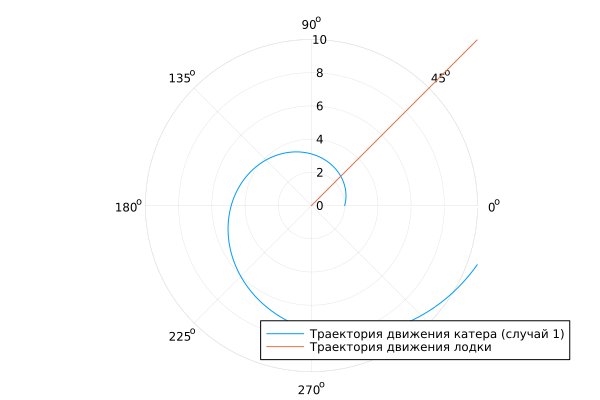

In [8]:
plot(sol.t, sol.u, proj=:polar, lims=(0, 10), label="Траектория движения катера (случай 1)") #передаем время и решение, t - угол
#u - радиус
plot!(ugol, x_lims, proj=:polar, lims=(0, 10), label="Траектория движения лодки")

Точное решение ДУ, описывающего движение катера береговой охраны

In [9]:
y(x) = (9.4 * exp(x/sqrt(12.69))) / 4.7

y (generic function with 1 method)

Подставим в точное решение угол, под которым движется лодка браконьеров для нахождения точки пересечения

In [10]:
y_result = y(fi)

2.4933371596324343

Точка пересечения лодки и катера для 1 случая

Точка пересечения лодки и катера для 1 случая: 2.4933371596324343


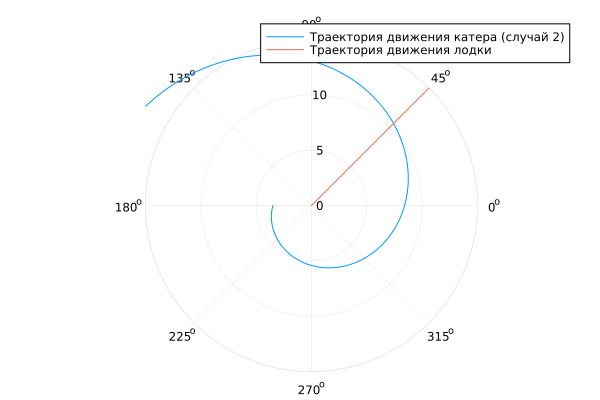

In [11]:
println("Точка пересечения лодки и катера для 1 случая: ", y_result)

plot(sol_2.t, sol_2.u, proj=:polar, lims=(0, 15), label="Траектория движения катера (случай 2)")

plot!(ugol, x_lims, proj=:polar, lims=(0, 15), label="Траектория движения лодки")

Точное решение ДУ, описывающего движение катера береговой охраны для 2 случая

In [12]:
y2(x) = (9.4 * exp((x+pi) / sqrt(12.69)))/ 2.7

y2 (generic function with 1 method)

Подставим в точное решение угол, под которым движется лодка браконьеров для нахождения точки пересечения

In [13]:
y2_result = y2(fi)

10.483810426356325

Точка пересечения лодки и катера для 2 случая

In [14]:
println("Точка пересечения лодки и катера для 2 случая: ", y2_result)

Точка пересечения лодки и катера для 2 случая: 10.483810426356325


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*